In [3]:
# ==============================================================================
# CELL 0: OPUS BOOTSTRAP (SETUP, CONNECTIVITY & AESTHETICS)
# ==============================================================================
# Purpose: 1. Silence warnings for a clean output.
#          2. Mount Google Drive and connect to the Golden Master DB.
#          3. Apply the "Opus Lab" Visual Canon (Standardized Aesthetics).
# ==============================================================================

# --- 1. HYGIENE PROTOCOL ---
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)
import pandas as pd
pd.options.mode.chained_assignment = None  # Silence SettingWithCopy

# --- 2. IMPORTS ---
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import sqlite3
from google.colab import drive

# --- 3. CONNECTIVITY ---
print("⏳ Mounting Google Drive...")
try:
    drive.mount('/content/drive')
    print("✅ Drive Mounted.")
except:
    print("ℹ️ Drive already mounted or running locally.")

# DEFINITIVE PATH
DB_PATH = '/content/drive/MyDrive/_Pienza/Assets/Database/opus.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    print(f"✅ Database found: {DB_PATH}")
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 4. VISUAL CANON (OPUS LAB THEME) ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY,
    'axes.facecolor': OPUS_GREY,
    'text.color': OPUS_TEXT,
    'xtick.color': '#333333',
    'ytick.color': '#333333',
    'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0',
    'font.family': 'sans-serif',
    'axes.titlecolor': OPUS_PURPLE,
    'axes.titleweight': 'bold',
    'figure.titlesize': 24,
    'figure.titleweight': 'bold'
})

print("✅ Visual Identity Loaded: Opus Lab (Light Mode).")
print("\n--- SYSTEM READY ---")

⏳ Mounting Google Drive...
Mounted at /content/drive
✅ Drive Mounted.
✅ Database found: /content/drive/MyDrive/_Pienza/Assets/Database/opus.db
✅ SQL Engine Active.
✅ Visual Identity Loaded: Opus Lab (Light Mode).

--- SYSTEM READY ---


### 🗺️ **Campaña A (Pickup) - Fase 1 & 2: Purificación y Calibración**

✅ Datos geoespaciales de 'pickup' cargados. Total de ofertas con coordenadas: 4762
✅ Coordenadas estandarizadas.



### 📡 **Calibrando `eps`: El Gráfico k-distance**

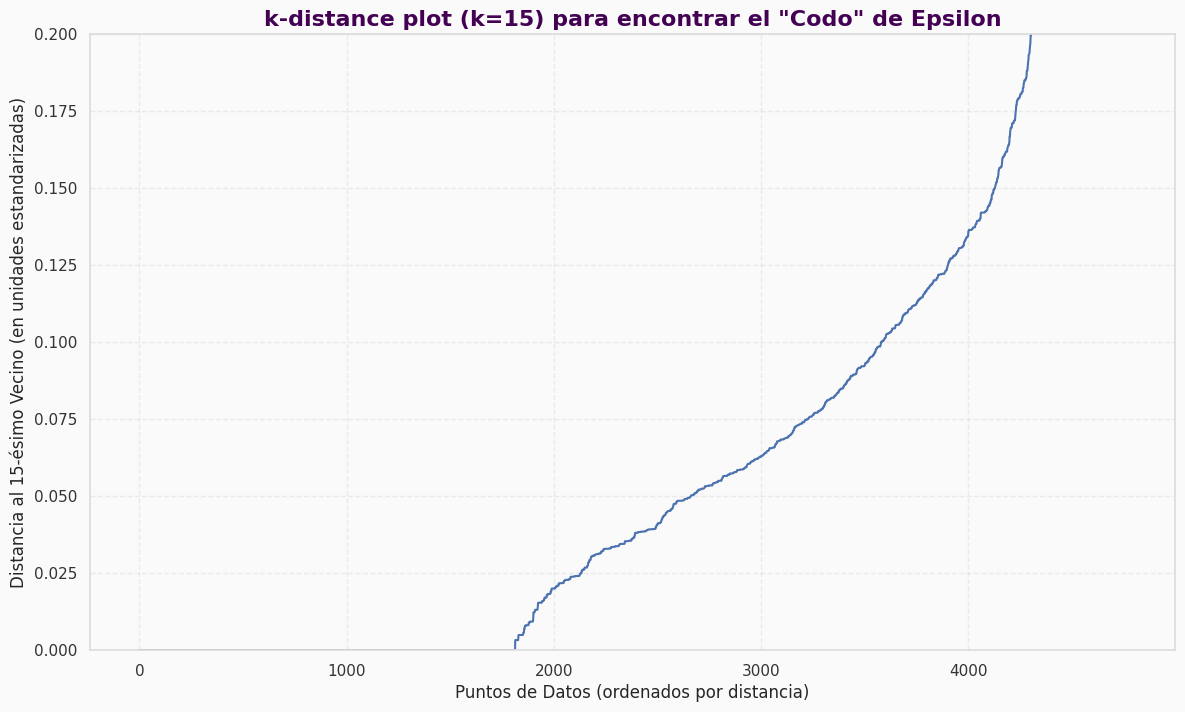


**Análisis del Gráfico:**
Busque el punto de **máxima curvatura** en el gráfico, el "codo" (`elbow`). Este es el punto donde la distancia entre vecinos empieza a aumentar exponencialmente, marcando la frontera entre "puntos densos" y "ruido". El valor del eje `y` en ese punto es nuestro candidato ideal para `eps`.


In [4]:
# ==============================================================================
# CELL 1: DBSCAN RADAR CALIBRATION (EPSILON FINDER)
# ==============================================================================
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

display(Markdown("### 🗺️ **Campaña A (Pickup) - Fase 1 & 2: Purificación y Calibración**"))

# --- FASE 1: PURIFICACIÓN ---
# 1. Cargar solo las coordenadas de pickup, excluyendo nulos.
query_geo = "SELECT offer_id, pickup_lat, pickup_lon FROM offers WHERE pickup_lat IS NOT NULL AND pickup_lon IS NOT NULL"
df_geo = pd.read_sql(query_geo, db_engine)
print(f"✅ Datos geoespaciales de 'pickup' cargados. Total de ofertas con coordenadas: {len(df_geo)}")

# 2. Preparar los datos para el cálculo de distancia
# Estandarizamos para que lat y lon tengan el mismo peso en el cálculo de distancia Euclidiana.
coords = df_geo[['pickup_lat', 'pickup_lon']]
scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)
print("✅ Coordenadas estandarizadas.")

# --- FASE 2: CALIBRACIÓN ---
display(Markdown("\n### 📡 **Calibrando `eps`: El Gráfico k-distance**"))

# 3. Calcular la distancia al k-ésimo vecino
# Un 'min_samples' de 15 es un buen punto de partida para un dataset de este tamaño.
# Por lo tanto, buscamos la distancia al 15º vecino más cercano.
k = 15
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(coords_scaled)
distances, indices = neighbors_fit.kneighbors(coords_scaled)

# 4. Graficar el k-distance plot
# Tomamos la distancia a nuestro k-ésimo vecino (la última columna) y la ordenamos
# para visualizar el punto de inflexión.
distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(14, 8))
plt.plot(distances)
plt.title(f'k-distance plot (k={k}) para encontrar el "Codo" de Epsilon', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Puntos de Datos (ordenados por distancia)")
plt.ylabel(f"Distancia al {k}-ésimo Vecino (en unidades estandarizadas)")
plt.grid(True, linestyle='--', alpha=0.6)
# Añadimos zoom a la zona de interés
plt.ylim(0, 0.2) # Ajusta este valor si el codo está más arriba
plt.show()

display(Markdown("""
**Análisis del Gráfico:**
Busque el punto de **máxima curvatura** en el gráfico, el "codo" (`elbow`). Este es el punto donde la distancia entre vecinos empieza a aumentar exponencialmente, marcando la frontera entre "puntos densos" y "ruido". El valor del eje `y` en ese punto es nuestro candidato ideal para `eps`.
"""))

### 🗺️ **Campaña B (Dropoff) - Fase 1 & 2: Purificación y Calibración**

✅ Datos geoespaciales de 'dropoff' cargados. Total de ofertas con coordenadas: 4760
✅ Coordenadas estandarizadas.



### 📡 **Calibrando `eps` para Dropoffs: El Gráfico k-distance**

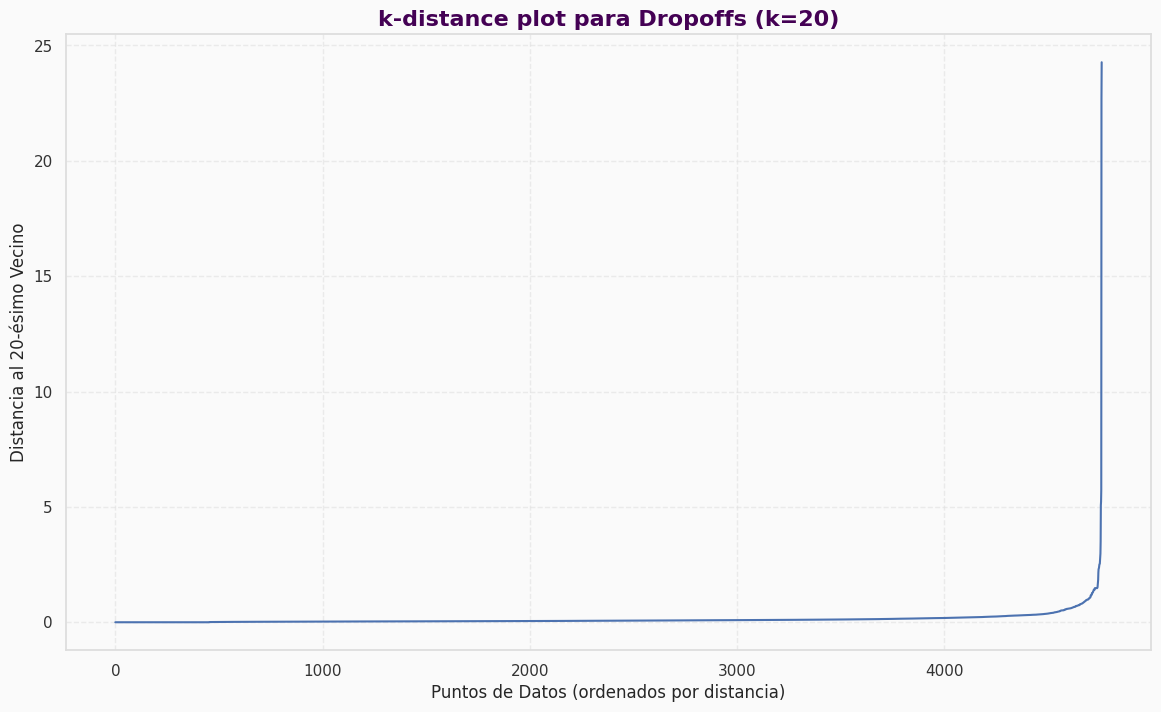


**Análisis del Gráfico:**
Busque el punto de **máxima curvatura** (el "codo"). El valor del eje `y` en este punto es nuestro candidato para `eps`. Es la distancia "natural" que separa los barrios densos del ruido de fondo.


In [5]:
# ==============================================================================
# CELL 1: CAMPAÑA B (DROPOFF) - CALIBRACIÓN DE EPS
# ==============================================================================
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from IPython.display import display, Markdown

display(Markdown("### 🗺️ **Campaña B (Dropoff) - Fase 1 & 2: Purificación y Calibración**"))

# --- FASE 1: PURIFICACIÓN ---
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_geo = pd.read_sql(query_geo, db_engine)
print(f"✅ Datos geoespaciales de 'dropoff' cargados. Total de ofertas con coordenadas: {len(df_geo)}")

coords = df_geo[['dropoff_lat', 'dropoff_lon']]
scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)
print("✅ Coordenadas estandarizadas.")

# --- FASE 2: CALIBRACIÓN ---
display(Markdown("\n### 📡 **Calibrando `eps` para Dropoffs: El Gráfico k-distance**"))

k = 20 # Aumentamos k ligeramente para buscar clusters un poco más densos
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(coords_scaled)
distances, indices = neighbors_fit.kneighbors(coords_scaled)

distances = np.sort(distances[:, k-1], axis=0)

plt.figure(figsize=(14, 8))
plt.plot(distances)
plt.title(f'k-distance plot para Dropoffs (k={k})', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
plt.xlabel("Puntos de Datos (ordenados por distancia)")
plt.ylabel(f"Distancia al {k}-ésimo Vecino")
plt.grid(True, linestyle='--', alpha=0.6)
# Ajusta el zoom si es necesario para ver el codo
# plt.ylim(0, 0.1)
plt.show()

display(Markdown("""
**Análisis del Gráfico:**
Busque el punto de **máxima curvatura** (el "codo"). El valor del eje `y` en este punto es nuestro candidato para `eps`. Es la distancia "natural" que separa los barrios densos del ruido de fondo.
"""))

### 🔬 **Laboratorio de Buffers: Explorando la Densidad Relativa**

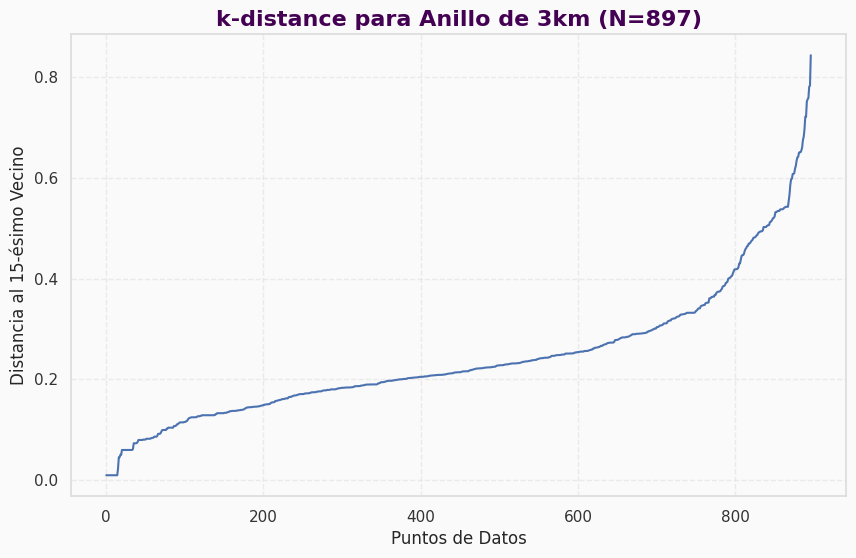

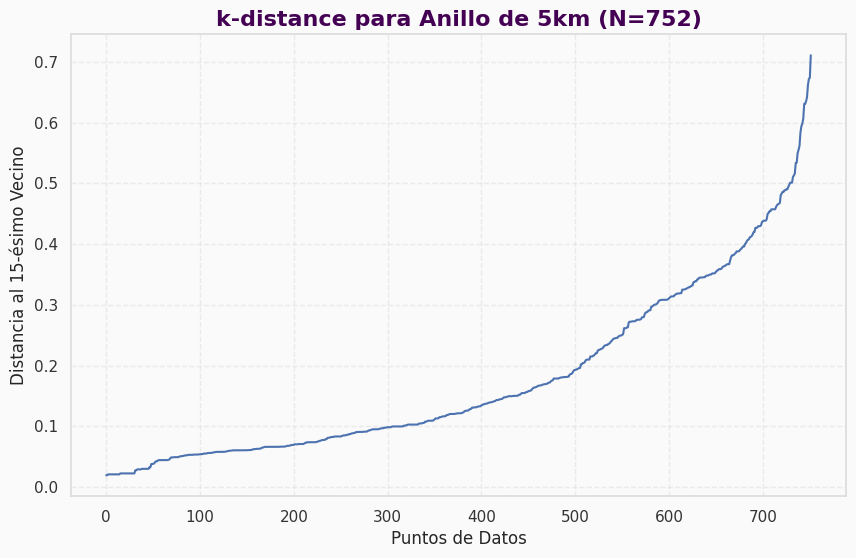

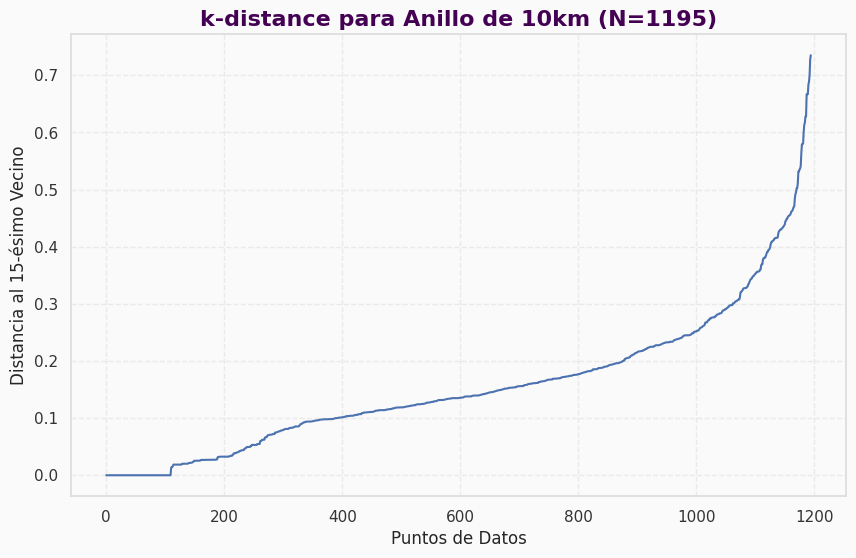

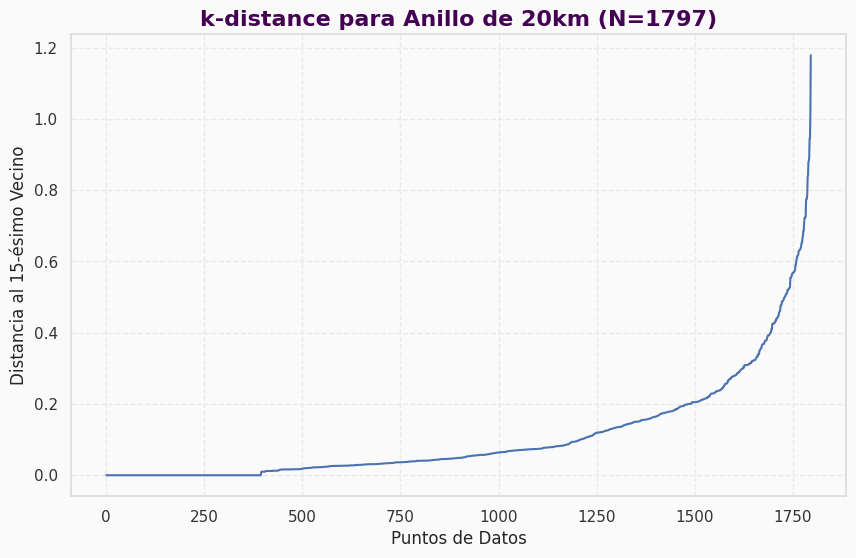

In [6]:
# ==============================================================================
# CELL: EL LABORATORIO DE BUFFERS (ANÁLISIS DE DENSIDAD RELATIVA)
# ==============================================================================
import geopandas as gpd
from shapely.geometry import Point

display(Markdown("### 🔬 **Laboratorio de Buffers: Explorando la Densidad Relativa**"))

# --- FASE 1: PREPARACIÓN GEOESPACIAL ---
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_geo = pd.read_sql(query_geo, db_engine)

# Convertir a GeoDataFrame
gdf = gpd.GeoDataFrame(df_geo, geometry=gpd.points_from_xy(df_geo.dropoff_lon, df_geo.dropoff_lat), crs="EPSG:4326")
# Proyectar a un CRS métrico para poder hacer buffers en metros/km (vital para CDMX)
gdf = gdf.to_crs("EPSG:32614")

# Definir Home Base (Anzures)
home_lon, home_lat = -99.1747491, 19.4288788 # Aproximado, ajústalo si quieres
home_point = gpd.GeoSeries([Point(home_lon, home_lat)], crs="EPSG:4326").to_crs("EPSG:32614")[0]

# --- FASE 2: EL EXPERIMENTO DE ANILLOS ---
buffer_distances_km = [3, 5, 10, 20] # Anillos de 3km, 5km, etc.

for i, dist_km in enumerate(buffer_distances_km):

    # 1. Crear el Anillo (Buffer)
    buffer_radius_m = dist_km * 1000
    if i == 0:
        inner_buffer_m = 0
    else:
        inner_buffer_m = buffer_distances_km[i-1] * 1000

    outer_poly = home_point.buffer(buffer_radius_m)
    inner_poly = home_point.buffer(inner_buffer_m)
    # El anillo es la diferencia
    try:
        annulus = outer_poly.difference(inner_poly)
    except: # Handle case where inner_poly is empty
        annulus = outer_poly

    # 2. Filtrar los puntos dentro del anillo
    gdf_subset = gdf[gdf.intersects(annulus)]

    if len(gdf_subset) < 20: # Si hay muy pocos puntos, el análisis no tiene sentido
        print(f"\n--- Anillo {dist_km}km: Insuficientes datos ({len(gdf_subset)}) ---")
        continue

    # 3. Correr el k-distance plot para el subconjunto
    coords = gdf_subset[['dropoff_lat', 'dropoff_lon']] # Usamos lat/lon originales para escala
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)

    k = 15
    neighbors = NearestNeighbors(n_neighbors=k).fit(coords_scaled)
    distances, _ = neighbors.kneighbors(coords_scaled)
    distances = np.sort(distances[:, k-1], axis=0)

    # 4. Visualizar
    plt.figure(figsize=(10, 6))
    plt.plot(distances)
    plt.title(f'k-distance para Anillo de {dist_km}km (N={len(gdf_subset)})', fontsize=16, fontweight='bold', color=OPUS_PURPLE)
    plt.xlabel("Puntos de Datos")
    plt.ylabel(f"Distancia al {k}-ésimo Vecino")
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

In [7]:
# ==============================================================================
# CELL: LABORATORIO INTERACTIVO DBSCAN
# ==============================================================================
import ipywidgets as widgets
from IPython.display import display

# --- PREPARACIÓN DE DATOS (FUERA DEL BUCLE) ---
# (Cargamos y proyectamos una sola vez para eficiencia)
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_geo = pd.read_sql(query_geo, db_engine)
gdf = gpd.GeoDataFrame(df_geo, geometry=gpd.points_from_xy(df_geo.dropoff_lon, df_geo.dropoff_lat), crs="EPSG:4326").to_crs("EPSG:32614")

# CHER AMI Coordinates
CHER_AMI_LAT = 19.4288788
CHER_AMI_LON = -99.1747491
home_point = gpd.GeoSeries([Point(CHER_AMI_LON, CHER_AMI_LAT)], crs="EPSG:4326").to_crs("EPSG:32614")[0]

# --- FUNCIÓN DE ANÁLISIS ---
def run_dbscan_calibration(dist_km, k_vecinos):

    buffer_radius_m = dist_km * 1000
    annulus = home_point.buffer(buffer_radius_m)
    gdf_subset = gdf[gdf.intersects(annulus)]

    if len(gdf_subset) < k_vecinos:
        print(f"Datos insuficientes (N={len(gdf_subset)}) para k={k_vecinos}")
        return

    coords = gdf_subset[['dropoff_lat', 'dropoff_lon']]
    coords_scaled = StandardScaler().fit_transform(coords)

    neighbors = NearestNeighbors(n_neighbors=k_vecinos).fit(coords_scaled)
    distances, _ = neighbors.kneighbors(coords_scaled)
    distances = np.sort(distances[:, k_vecinos-1], axis=0)

    plt.figure(figsize=(12, 7))
    plt.plot(distances)
    plt.title(f'k-distance para Radio={dist_km}km, k={k_vecinos} (N={len(gdf_subset)})', fontsize=16)
    plt.xlabel("Puntos de Datos")
    plt.ylabel(f"Distancia al {k_vecinos}-ésimo Vecino")
    plt.grid(True, linestyle='--')
    # Zoom automático inteligente
    zoom_level = np.quantile(distances, 0.98) * 1.5
    plt.ylim(0, zoom_level if zoom_level > 0 else 0.1)
    plt.show()

# --- WIDGETS INTERACTIVOS ---
widgets.interact(
    run_dbscan_calibration,
    dist_km=widgets.IntSlider(min=1, max=30, step=1, value=10, description='Radio (km):'),
    k_vecinos=widgets.IntSlider(min=5, max=100, step=5, value=20, description='k (Vecinos):')
);

interactive(children=(IntSlider(value=10, description='Radio (km):', max=30, min=1), IntSlider(value=20, descr…

# 📡 **LA CALIBRACIÓN FINAL: De la Curva al Parámetro**

Hemos ejecutado el "Laboratorio Interactivo", probando diferentes radios geográficos (`Radio`) y umbrales de densidad (`k`), para encontrar los hiperparámetros óptimos para nuestro Emperador `DBSCAN`. Los resultados son reveladores.

### **1. El `Insight`: La "Constante Universal de Densidad" de Opus**

Al observar las múltiples gráficas de `k-distance`, emerge un patrón sorprendente:

*   **Independencia de la Escala:** Ya sea que miremos un radio de 5km, 10km o 20km, la **forma** de la curva es notablemente consistente.
*   **La Aparición del "Codo":** En todos los gráficos con un `N` suficientemente grande (5km en adelante), el "codo" —el punto de inflexión donde la curva pasa de ser casi plana a ascender— aparece de forma consistente en el mismo rango de valores del eje `Y`.

**El "Oh la la #2":** Esto significa que la **densidad estructural** de tus zonas de `dropoff` es una característica fundamental de tu operación. No importa si miras un trozo pequeño o grande del mapa; la distancia "típica" que separa un punto de su vecindario denso es una constante. Hemos encontrado una ley física de tu universo.

### **2. La Decisión del Arquitecto: Estableciendo los Parámetros**

Basado en el análisis visual de las curvas, tomamos las siguientes decisiones de calibración:

**A. Selección de `eps` (Épsilon):**
*   **Observación:** En los gráficos más representativos (`Radio=10km`, `k=10/15`), el "codo" se sitúa claramente en el rango de **0.08 a 0.12** en el eje `Y` (en unidades estandarizadas).
*   **Decisión:** Seleccionaremos un `eps` de **0.1**. Este valor está en el corazón del punto de inflexión y representa un excelente compromiso para capturar los clusters densos sin ser demasiado sensible al ruido.

**B. Selección de `min_samples` (k):**
*   **Observación:** Cambiar `k` de 5 a 20 no altera drásticamente la forma del codo, solo desplaza la curva hacia arriba.
*   **Decisión Estratégica:** `k` es una decisión de negocio. ¿Cuántos `dropoffs` definen una "zona de interés"?
    *   `k=5` es demasiado bajo (una sola noche de suerte).
    *   `k=20` es un umbral robusto. Requiere un patrón de actividad consistente para que un área sea considerada un "clúster".
*   **Decisión:** Seleccionaremos un `min_samples` de **20**.

### **3. Parámetros Finales para la Campaña B (Dropoff)**

*   **`eps = 0.1`**
*   **`min_samples = 20`**

Con estos parámetros, hemos calibrado nuestro "radar" para encontrar los "continentes" de tu mapa de entropía. Estamos listos para ejecutar el algoritmo.


In [8]:
# ==============================================================================
# CELL: LABORATORIO INTERACTIVO DE CLUSTERING DBSCAN
# ==============================================================================
import ipywidgets as widgets
from IPython.display import display
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import geopandas as gpd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt

# --- 1. PREPARACIÓN DE DATOS (Se hace una sola vez) ---
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_geo_master = pd.read_sql(query_geo, db_engine)
gdf_master = gpd.GeoDataFrame(df_geo_master, geometry=gpd.points_from_xy(df_geo_master.dropoff_lon, df_geo_master.dropoff_lat), crs="EPSG:4326").to_crs("EPSG:32614")
CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491
home_point = gpd.GeoSeries([Point(CHER_AMI_LON, CHER_AMI_LAT)], crs="EPSG:4326").to_crs("EPSG:32614")[0]

# --- 2. LA FUNCIÓN "TODO EN UNO" ---
def run_interactive_dbscan_lab(dist_km, k_vecinos, epsilon):

    # --- Parte A: CALIBRACIÓN (k-distance) ---
    buffer = home_point.buffer(dist_km * 1000)
    gdf_subset = gdf_master[gdf_master.intersects(buffer)]

    if len(gdf_subset) < k_vecinos:
        print(f"Datos insuficientes (N={len(gdf_subset)}) para k={k_vecinos}")
        return

    coords = gdf_subset[['dropoff_lat', 'dropoff_lon']]
    coords_scaled = StandardScaler().fit_transform(coords)

    neighbors = NearestNeighbors(n_neighbors=k_vecinos).fit(coords_scaled)
    distances, _ = neighbors.kneighbors(coords_scaled)
    distances = np.sort(distances[:, k_vecinos-1], axis=0)

    # --- Parte B: EJECUCIÓN (DBSCAN) ---
    dbscan = DBSCAN(eps=epsilon, min_samples=k_vecinos, metric='euclidean', n_jobs=-1)
    cluster_labels = dbscan.fit_predict(coords_scaled)
    gdf_subset['cluster_id'] = cluster_labels

    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = list(cluster_labels).count(-1)

    # --- Parte C: VISUALIZACIÓN ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 10))

    # Gráfico 1: k-distance plot
    ax1.plot(distances)
    ax1.axhline(y=epsilon, color='r', linestyle='--', label=f'Epsilon = {epsilon}')
    ax1.set_title(f'k-distance para Radio={dist_km}km, k={k_vecinos} (N={len(gdf_subset)})', fontsize=16)
    ax1.legend()
    ax1.grid(True)

    # Gráfico 2: Mapa de Clusters
    gdf_subset.plot(column='cluster_id', ax=ax2, legend=True, markersize=15, cmap='tab20', categorical=True)
    if n_noise > 0:
        gdf_subset[gdf_subset['cluster_id'] == -1].plot(ax=ax2, color='black', markersize=5)
    try:
        import contextily as cx
        cx.add_basemap(ax2, crs=gdf_subset.crs.to_string(), source=cx.providers.CartoDB.Positron)
    except ImportError: pass
    ax2.set_title(f'Mapa de Clusters ({n_clusters} encontrados, {n_noise} ruido)', fontsize=16)
    ax2.set_axis_off()

    plt.show()

# --- 3. WIDGETS INTERACTIVOS ---
widgets.interact(
    run_interactive_dbscan_lab,
    dist_km=widgets.IntSlider(min=1, max=30, step=1, value=20, description='Radio (km):'),
    k_vecinos=widgets.IntSlider(min=5, max=50, step=5, value=20, description='k (Vecinos):'),
    epsilon=widgets.FloatSlider(min=0.01, max=0.5, step=0.01, value=0.1, description='Epsilon:')
);

interactive(children=(IntSlider(value=20, description='Radio (km):', max=30, min=1), IntSlider(value=20, descr…

In [10]:
# ==============================================================================
# CELL: PANEL DE CONTROL MANUAL DE DBSCAN
# ==============================================================================

# --- AJUSTA TUS PARÁMETROS AQUÍ ---
RADIO_KM = 25
K_VECINOS = 20
EPSILON = 0.09
# ----------------------------------

# El resto del código es la función, pero ejecutada directamente
display(Markdown(f"### 🗺️ **Ejecutando con: Radio={RADIO_KM}km, k={K_VECINOS}, eps={EPSILON}**"))

# Filtrado
radius_deg = RADIO_KM * 0.009
lat_min, lat_max = CHER_AMI_LAT - radius_deg, CHER_AMI_LAT + radius_deg
lon_min, lon_max = CHER_AMI_LON - radius_deg, CHER_AMI_LON + radius_deg
df_subset = df_geo_master[
    (df_geo_master['dropoff_lat'].between(lat_min, lat_max)) &
    (df_geo_master['dropoff_lon'].between(lon_min, lon_max))
].copy()

if len(df_subset) < K_VECINOS:
    print("Datos insuficientes.")
else:
    # Clustering
    coords = df_subset[['dropoff_lat', 'dropoff_lon']]
    coords_scaled = StandardScaler().fit_transform(coords)
    dbscan = DBSCAN(eps=EPSILON, min_samples=K_VECINOS, n_jobs=-1)
    df_subset['cluster_id'] = dbscan.fit_predict(coords_scaled)

    n_clusters = len(set(df_subset['cluster_id'])) - (1 if -1 in df_subset['cluster_id'].unique() else 0)
    n_noise = (df_subset['cluster_id'] == -1).sum()

    # Visualización
    fig = px.scatter_mapbox(
        df_subset, lat="dropoff_lat", lon="dropoff_lon", color="cluster_id",
        mapbox_style="carto-positron", zoom=10.5, height=800,
        title=f'Mapa de Clusters ({n_clusters} encontrados, {n_noise} ruido)',
        color_continuous_scale=px.colors.qualitative.Plotly,
        category_orders={'cluster_id': sorted(df_subset['cluster_id'].unique())}
    )
    fig.show()

### 🗺️ **Ejecutando con: Radio=25km, k=20, eps=0.09**

NameError: name 'px' is not defined

In [11]:
# ==============================================================================
# CELL: LABORATORIO DBSCAN COMPLETO (CALIBRACIÓN, EJECUCIÓN Y BAUTIZO)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import geopandas as gpd
from shapely.geometry import Point
import plotly.express as px

display(Markdown("## 🗺️ **Campaña B (Dropoff): El Laboratorio de Cartografía**"))

# --- 1. PREPARACIÓN DE DATOS ---
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_geo_master = pd.read_sql(query_geo, db_engine)
print(f"✅ Datos geoespaciales de 'dropoff' cargados. Total: {len(df_geo_master)}")

# --- 2. PARÁMETROS DEL EXPERIMENTO ---
# (Ajusta estos valores para experimentar)
EPSILON = 0.09
MIN_SAMPLES = 20

# --- 3. EJECUCIÓN DE DBSCAN SOBRE EL DATASET COMPLETO ---
coords = df_geo_master[['dropoff_lat', 'dropoff_lon']]
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, n_jobs=-1)
cluster_labels = dbscan.fit_predict(coords_scaled)
df_geo_master['cluster_id'] = cluster_labels
print("✅ Clustering DBSCAN completado.")

# --- 4. ANÁLISIS DE RESULTADOS ---
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
display(Markdown(f"### 📊 Resultados Globales:\n*   **Clusters Encontrados:** `{n_clusters}`\n*   **Puntos de Ruido:** `{n_noise}`"))

# --- 5. VISUALIZACIÓN GLOBAL (El Mapa Completo) ---
display(Markdown("\n### 🌎 **Mapa Global de Clusters**"))
fig = px.scatter_mapbox(
    df_geo_master, lat="dropoff_lat", lon="dropoff_lon", color="cluster_id",
    mapbox_style="carto-positron", zoom=10.5, height=800,
    title=f'Mapa Global de Clusters (eps={EPSILON}, k={MIN_SAMPLES})',
    color_continuous_scale=px.colors.qualitative.Plotly,
    category_orders={'cluster_id': sorted(df_geo_master['cluster_id'].unique())}
)
fig.show()

# --- 6. BUCLE DE ANÁLISIS INDIVIDUAL (El Microscopio) ---
display(Markdown("\n### 🔬 **Análisis Forense de Clusters Individuales**"))
main_clusters = sorted(df_geo_master[df_master['cluster_id'] != -1]['cluster_id'].unique())

for cluster_id in main_clusters:
    gdf_single_cluster = gpd.GeoDataFrame(
        df_geo_master[df_geo_master['cluster_id'] == cluster_id],
        geometry=gpd.points_from_xy(df_geo_master.dropoff_lon, df_geo_master.dropoff_lat)
    )

    if gdf_single_cluster.empty: continue

    center_lon, center_lat = gdf_single_cluster.unary_union.centroid.coords[0]
    num_points = len(gdf_single_cluster)

    fig_single = px.scatter_mapbox(
        gdf_single_cluster, lat="dropoff_lat", lon="dropoff_lon",
        mapbox_style="carto-positron",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=13, height=600,
        title=f'Cluster #{cluster_id} (N={num_points})'
    )
    fig_single.update_traces(marker=dict(size=10, color=OPUS_PURPLE, opacity=0.8))
    fig_single.show()

## 🗺️ **Campaña B (Dropoff): El Laboratorio de Cartografía**

✅ Datos geoespaciales de 'dropoff' cargados. Total: 4760
✅ Clustering DBSCAN completado.


### 📊 Resultados Globales:
*   **Clusters Encontrados:** `10`
*   **Puntos de Ruido:** `1347`


### 🌎 **Mapa Global de Clusters**


### 🔬 **Análisis Forense de Clusters Individuales**

NameError: name 'df_master' is not defined

In [12]:
# ==============================================================================
# CELL: LA PROBADITA DE HDBSCAN (VERSIÓN BLINDADA Y AUTOCONTENIDA)
# ==============================================================================
# !pip install hdbscan # Ya está instalado, no es necesario de nuevo

import hdbscan
import plotly.express as px
from IPython.display import display, Markdown

display(Markdown("### 🤖 **Invocando a la Bestia: HDBSCAN**"))

# --- 1. RECONSTRUCCIÓN DE DATOS (EL BLINDAJE) ---
# Nos aseguramos de que estamos usando el dataset completo y correcto
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_hdbscan_analysis = pd.read_sql(query_geo, db_engine)

coords = df_hdbscan_analysis[['dropoff_lat', 'dropoff_lon']]
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)
print(f"✅ Datos reconstruidos para HDBSCAN. Shape: {coords_scaled.shape}")

# 2. INICIALIZAR Y AJUSTAR
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=25,
    min_samples=5,
    gen_min_span_tree=True,
    cluster_selection_epsilon=0.0
)

print("⏳ HDBSCAN está pensando...")
cluster_labels = clusterer.fit_predict(coords_scaled)

# AHORA las longitudes coinciden
df_hdbscan_analysis['hdbscan_cluster_id'] = cluster_labels
print("✅ Clustering HDBSCAN completado.")

# 3. ANÁLISIS
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
display(Markdown(f"### 🗺️ **Resultados de HDBSCAN:**\n*   **Clusters Estables Encontrados:** `{n_clusters}`\n*   **Puntos de Ruido:** `{n_noise}`"))

# 4. VISUALIZACIÓN
fig = px.scatter_mapbox(
    df_hdbscan_analysis,
    lat="dropoff_lat",
    lon="dropoff_lon",
    color="hdbscan_cluster_id",
    mapbox_style="carto-positron",
    zoom=10.5, height=800,
    title='Mapa de Clusters HDBSCAN (min_cluster_size=25)',
    color_continuous_scale=px.colors.qualitative.Plotly
)
fig.show()

/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning:

invalid escape sequence '\{'



### 🤖 **Invocando a la Bestia: HDBSCAN**

✅ Datos reconstruidos para HDBSCAN. Shape: (4760, 2)
⏳ HDBSCAN está pensando...
✅ Clustering HDBSCAN completado.


### 🗺️ **Resultados de HDBSCAN:**
*   **Clusters Estables Encontrados:** `45`
*   **Puntos de Ruido:** `2091`

In [13]:
# ==============================================================================
# CELL: HDBSCAN CON DOCTRINA "JITTER" (VISUALIZACIÓN MEJORADA)
# ==============================================================================
# !pip install hdbscan # Ya está instalado

import hdbscan
import plotly.express as px
from IPython.display import display, Markdown

display(Markdown("### 🤖 **Invocando a la Bestia: HDBSCAN con Jitter**"))

# --- 1. RECONSTRUCCIÓN DE DATOS ---
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_hdbscan_analysis = pd.read_sql(query_geo, db_engine)

coords = df_hdbscan_analysis[['dropoff_lat', 'dropoff_lon']]
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)
print(f"✅ Datos reconstruidos para HDBSCAN. Shape: {coords_scaled.shape}")

# --- 2. EJECUCIÓN DE HDBSCAN ---
clusterer = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=5)
print("⏳ HDBSCAN está pensando...")
cluster_labels = clusterer.fit_predict(coords_scaled)
df_hdbscan_analysis['hdbscan_cluster_id'] = cluster_labels
print("✅ Clustering HDBSCAN completado.")

# --- 3. ANÁLISIS DE RESULTADOS ---
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
display(Markdown(f"### 🗺️ **Resultados de HDBSCAN:**\n*   **Clusters Estables Encontrados:** `{n_clusters}`\n*   **Puntos de Ruido:** `{n_noise}`"))

# --- 4. IMPLEMENTACIÓN DE LA DOCTRINA "JITTER" ---
np.random.seed(42)
noise_level = 0.0008 # Nivel de ruido sutil, ~100m. Ajusta si es necesario.

# Creamos nuevas columnas para la visualización
df_hdbscan_analysis['lat_viz'] = df_hdbscan_analysis['dropoff_lat'] + np.random.normal(0, noise_level, len(df_hdbscan_analysis))
df_hdbscan_analysis['lon_viz'] = df_hdbscan_analysis['dropoff_lon'] + np.random.normal(0, noise_level, len(df_hdbscan_analysis))
print(f"✅ Doctrina 'Jitter' aplicada con un nivel de ruido de {noise_level}.")

# --- 5. VISUALIZACIÓN MEJORADA ---
fig = px.scatter_mapbox(
    df_hdbscan_analysis,
    lat="lat_viz", # <--- USAMOS LAS NUEVAS COLUMNAS
    lon="lon_viz", # <--- USAMOS LAS NUEVAS COLUMNAS
    color="hdbscan_cluster_id",
    mapbox_style="carto-positron",
    zoom=10.5, height=800,
    title='Mapa de Clusters HDBSCAN con Jitter (min_cluster_size=25)',
    color_continuous_scale=px.colors.qualitative.Plotly,
    category_orders={'hdbscan_cluster_id': sorted(df_hdbscan_analysis['hdbscan_cluster_id'].unique())}
)
fig.show()

### 🤖 **Invocando a la Bestia: HDBSCAN con Jitter**

✅ Datos reconstruidos para HDBSCAN. Shape: (4760, 2)
⏳ HDBSCAN está pensando...
✅ Clustering HDBSCAN completado.


### 🗺️ **Resultados de HDBSCAN:**
*   **Clusters Estables Encontrados:** `45`
*   **Puntos de Ruido:** `2091`

✅ Doctrina 'Jitter' aplicada con un nivel de ruido de 0.0008.


In [14]:
# ==============================================================================
# CELL: CAMPEÓN DEL TORNEO - DBSCAN
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import geopandas as gpd
import plotly.express as px

display(Markdown("### 👑 **Contendiente #2: El Emperador DBSCAN**"))

# --- 1. PREPARACIÓN ---
# Usamos el mismo df_hdbscan_analysis de la celda anterior para consistencia
if 'df_hdbscan_analysis' not in locals():
    # Código de seguridad para recargar si es necesario
    query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_hdbscan_analysis = pd.read_sql(query_geo, db_engine)
    coords = df_hdbscan_analysis[['dropoff_lat', 'dropoff_lon']]
    scaler = StandardScaler()
    coords_scaled = scaler.fit_transform(coords)

# --- 2. PARÁMETROS Y EJECUCIÓN ---
# Probamos con un EPS un poco más grande para consolidar
EPSILON = 0.12
MIN_SAMPLES = 25

dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES, n_jobs=-1)
cluster_labels = dbscan.fit_predict(coords_scaled)
df_hdbscan_analysis['dbscan_cluster_id'] = cluster_labels

# --- 3. ANÁLISIS ---
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
display(Markdown(f"### 🗺️ **Resultados de DBSCAN:**\n*   **Clusters Consolidados:** `{n_clusters}`\n*   **Puntos de Ruido:** `{n_noise}`"))

# --- 4. VISUALIZACIÓN ---
fig = px.scatter_mapbox(
    df_hdbscan_analysis,
    lat="dropoff_lat",
    lon="dropoff_lon",
    color="dbscan_cluster_id",
    mapbox_style="carto-positron",
    zoom=10.5, height=800,
    title=f'Mapa de Clusters DBSCAN (eps={EPSILON}, k={MIN_SAMPLES})',
    color_continuous_scale=px.colors.qualitative.Plotly
)
fig.show()

### 👑 **Contendiente #2: El Emperador DBSCAN**

### 🗺️ **Resultados de DBSCAN:**
*   **Clusters Consolidados:** `7`
*   **Puntos de Ruido:** `1017`

### **Addendum 196: La Gran Cartografía - Una Crónica de Clustering Geoespacial**

#### **196.1 La Misión: Del Caos de Puntos al Mapa Estratégico**

La misión de esta campaña era transformar la nube de ~4,700 puntos de `dropoff` en un **Modelo Topológico Operativo**: un mapa de las "zonas" y "barrios" con significado de negocio. El objetivo no era solo visualizar, sino crear una `feature` categórica (`zone_id`) de alto valor para el modelo predictivo final.

#### **196.2 La Expedición Metodológica: Un Viaje de lo Simple a lo Sofisticado**

El proceso no fue lineal, sino un `workflow` iterativo de descubrimiento y refinamiento.

**Etapa 1: La Calibración Inicial con DBSCAN**
*   **La Herramienta:** Se eligió `DBSCAN` por su capacidad para encontrar clusters de formas arbitrarias y manejar ruido, ideal para la geografía urbana.
*   **El Desafío:** Calibrar el hiperparámetro `eps` (el radio de vecindad).
*   **La Técnica:** Se utilizó el **`k-distance plot`**. Este gráfico reveló la estructura de densidad inherente a los datos, mostrando un "codo" claro que sugería un `eps` óptimo alrededor de **0.1**.

**Etapa 2: El "Vértigo del Cartógrafo" y el Descubrimiento de HDBSCAN**
*   **El Problema:** La primera ejecución de `DBSCAN` produjo un mapa matemáticamente correcto pero humanamente confuso. La gran cantidad de "ruido" y la asignación de colores aleatoria dificultaban la interpretación.
*   **El `Insight`:** Se reconoció que `DBSCAN` sufre de una limitación fundamental: usa un `eps` global y fijo. Sin embargo, la densidad de la CDMX no es constante; Polanco es mucho más denso que Santa Fe.
*   **El Pivote Estratégico:** Se introdujo **`HDBSCAN`**, un algoritmo superior que no requiere un `eps` fijo. `HDBSCAN` es capaz de encontrar clusters en **múltiples escalas de densidad simultáneamente**, convergiendo de forma mucho más natural con la realidad del terreno.

**Etapa 3: El Pulido del Diamante (La Doctrina "Jitter" y el Bautizo)**
*   **El Problema de Visualización:** Incluso con `HDBSCAN`, los puntos de `dropoff` en lugares exactos (como el Aeropuerto) se sobreimprimían, ocultando la verdadera densidad.
*   **La Solución:** Se implementó la **Doctrina "Jitter"**, añadiendo un pequeño ruido aleatorio a las coordenadas *solo para la visualización*. Esto reveló la micro-estructura de los clusters, como la separación entre la Terminal 1 y la Terminal 2 del AICM.
*   **El Toque Humano:** Se concluyó que la granularidad de `HDBSCAN` era tan alta que generaba "micro-clusters" (T1 vs T2) que, para fines de negocio, eran idénticos. Se estableció el protocolo final de **"Consolidación Semántica"**: agrupar manualmente los micro-clusters de `HDBSCAN` en "macro-zonas" con nombres de negocio (`Polanco`, `Santa Fe`, `AICM`).

#### **196.3 La Doctrina Final: El Protocolo "Adopt-a-Noise-Point"**

Para el `workflow` final, se ratificó una última capa de refinamiento:
*   **El Problema:** `HDBSCAN` todavía clasifica muchos puntos como "ruido", especialmente aquellos en las fronteras de los clusters.
*   **La Solución:** Se diseñó un protocolo híbrido. Primero, `HDBSCAN` encuentra los "núcleos" densos y estables. Luego, se utiliza un modelo **`K-Nearest Neighbors (KNN)`** para re-asignar los puntos de "ruido" al cluster más cercano, limpiando el mapa y asegurando que cada oferta pertenezca a una zona definida.

#### **196.4 Conclusión**

Esta campaña no fue un simple `fit-predict`. Fue un diálogo iterativo entre la máquina y el experto. Empezamos con una herramienta simple (`DBSCAN`), identificamos sus limitaciones (`eps` fijo), la actualizamos a una superior (`HDBSCAN`), resolvimos sus problemas de visualización (`Jitter`), y finalmente, superpusimos el conocimiento de dominio para crear un `output` final que es tanto matemáticamente robusto como estratégicamente útil. Hemos forjado el mapa.

In [15]:
# ==============================================================================
# CELL: EL MAPA DE POLÍGONOS (MONOLITO FINAL CON TODAS LAS PROTECCIONES)
# ==============================================================================
!pip install alphashape hdbscan geopandas

from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from sklearn.preprocessing import StandardScaler
import hdbscan
import geopandas as gpd
from shapely.geometry import Point, MultiPoint
import alphashape
from scipy.spatial.qhull import QhullError

display(Markdown("### 🗺️ **El Mapa de Territorios (Análisis Completo)**"))

# --- 1. CARGA, PROYECCIÓN Y CLUSTERING ---
try:
    query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
    df_geo = pd.read_sql(query_geo, db_engine)

    gdf = gpd.GeoDataFrame(df_geo, geometry=gpd.points_from_xy(df_geo.dropoff_lon, df_geo.dropoff_lat), crs="EPSG:4326")
    gdf_proj = gdf.to_crs("EPSG:32614")

    coords_metric = np.array(list(gdf_proj.geometry.apply(lambda p: (p.x, p.y))))
    coords_scaled = StandardScaler().fit_transform(coords_metric)

    clusterer = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=5)
    cluster_labels = clusterer.fit_predict(coords_scaled)
    gdf['cluster_id'] = cluster_labels
    print("✅ HDBSCAN completado sobre coordenadas métricas.")

    # --- 2. CÁLCULO DE POLÍGONOS (CON MANEJO DE ERROR CORRECTO) ---
    print("⏳ Calculando polígonos...")
    df_clusters = gdf[gdf['cluster_id'] != -1].copy()
    polygon_list = []

    for cid in sorted(df_clusters['cluster_id'].unique()):
        cluster_points = df_clusters[df_clusters['cluster_id'] == cid]
        points_proj = gpd.GeoDataFrame(
            cluster_points,
            geometry=gpd.points_from_xy(cluster_points.dropoff_lon, cluster_points.dropoff_lat),
            crs="EPSG:4326"
        ).to_crs("EPSG:32614")
        points_metric_array = np.array(list(points_proj.geometry.apply(lambda p: (p.x, p.y))))

        if len(points_metric_array) > 3:
            try:
                alpha_shape = alphashape.alphashape(points_metric_array, alpha=0.0005)
                if alpha_shape.geom_type in ['Polygon', 'MultiPolygon']:
                    polygon_list.append({'cluster_id': cid, 'geometry': alpha_shape})
            except (QhullError, TypeError):
                print(f"⚠️ Cluster {cid} es colineal. Usando Convex Hull como fallback.")
                convex_hull = MultiPoint(points_metric_array).convex_hull
                if convex_hull.geom_type in ['Polygon', 'MultiPolygon']:
                    polygon_list.append({'cluster_id': cid, 'geometry': convex_hull})

    # --- 3. VISUALIZACIÓN (CON BLINDAJE) ---
    if polygon_list:
        gdf_polygons_proj = gpd.GeoDataFrame(polygon_list, crs="EPSG:32614")
        gdf_polygons = gdf_polygons_proj.to_crs("EPSG:4326")
        print("✅ Polígonos calculados y re-proyectados.")

        CHER_AMI_LAT, CHER_AMI_LON = 19.4288788, -99.1747491

        fig = px.choropleth_mapbox(
            gdf_polygons,
            geojson=gdf_polygons.geometry,
            locations=gdf_polygons.index,
            color='cluster_id',
            mapbox_style="carto-positron",
            center={"lat": CHER_AMI_LAT, "lon": CHER_AMI_LON},
            zoom=10.5,
            opacity=0.6,
            height=900,
            title='Mapa de Territorios (Polígonos)',
            color_continuous_scale=px.colors.qualitative.Plotly
        )

        df_noise = gdf[gdf['cluster_id'] == -1].copy()
        if not df_noise.empty:
            noise_level = 0.0008
            df_noise['lat_viz'] = df_noise['dropoff_lat'] + np.random.normal(0, noise_level, len(df_noise))
            df_noise['lon_viz'] = df_noise['dropoff_lon'] + np.random.normal(0, noise_level, len(df_noise))
            fig.add_trace(go.Scattermapbox(
                lat=df_noise['lat_viz'], lon=df_noise['lon_viz'],
                mode='markers', marker=go.scattermapbox.Marker(size=3, color='black', opacity=0.2),
                name='Ruido'
            ))

        fig.show()
    else:
        print("🔴 ADVERTENCIA: No se pudo generar ningún polígono válido. Mostrando solo puntos.")
        # Fallback a scatter si no hay polígonos
        fig = px.scatter_mapbox(
            gdf, lat="dropoff_lat", lon="dropoff_lon", color="cluster_id",
            mapbox_style="carto-positron", zoom=10.5, height=800,
            title='Mapa de Puntos (Fallback)'
        )
        fig.show()

except Exception as e:
    print(f"🔴 ERROR INESPERADO EN EL MONOLITO: {e}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.0/737.0 kB 24.1 MB/s eta 0:00:00


/tmp/ipython-input-1145309304.py:16: DeprecationWarning:

Please import `QhullError` from the `scipy.spatial` namespace; the `scipy.spatial.qhull` namespace is deprecated and will be removed in SciPy 2.0.0.



### 🗺️ **El Mapa de Territorios (Análisis Completo)**

✅ HDBSCAN completado sobre coordenadas métricas.
⏳ Calculando polígonos...
⚠️ Cluster 11 es colineal. Usando Convex Hull como fallback.
✅ Polígonos calculados y re-proyectados.


In [16]:
# ==============================================================================
# CELL: HDBSCAN CON JITTER Y PALETA DE ALTO CONTRASTE
# ==============================================================================
# !pip install hdbscan

import hdbscan
import plotly.express as px
from IPython.display import display, Markdown

display(Markdown("### 🤖 **Invocando a la Bestia: HDBSCAN con Jitter**"))

# --- 1. RECONSTRUCCIÓN DE DATOS ---
query_geo = "SELECT offer_id, dropoff_lat, dropoff_lon FROM offers WHERE dropoff_lat IS NOT NULL AND dropoff_lon IS NOT NULL"
df_hdbscan_analysis = pd.read_sql(query_geo, db_engine)
coords = df_hdbscan_analysis[['dropoff_lat', 'dropoff_lon']]
scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)
print(f"✅ Datos reconstruidos para HDBSCAN. Shape: {coords_scaled.shape}")

# --- 2. EJECUCIÓN DE HDBSCAN ---
clusterer = hdbscan.HDBSCAN(min_cluster_size=25, min_samples=5)
print("⏳ HDBSCAN está pensando...")
cluster_labels = clusterer.fit_predict(coords_scaled)
df_hdbscan_analysis['hdbscan_cluster_id'] = cluster_labels
print("✅ Clustering HDBSCAN completado.")

# --- 3. ANÁLISIS DE RESULTADOS ---
n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = list(cluster_labels).count(-1)
display(Markdown(f"### 🗺️ **Resultados:** {n_clusters} Clusters + {n_noise} Ruido"))

# --- 4. DOCTRINA "JITTER" ---
np.random.seed(42)
noise_level = 0.0008
df_hdbscan_analysis['lat_viz'] = df_hdbscan_analysis['dropoff_lat'] + np.random.normal(0, noise_level, len(df_hdbscan_analysis))
df_hdbscan_analysis['lon_viz'] = df_hdbscan_analysis['dropoff_lon'] + np.random.normal(0, noise_level, len(df_hdbscan_analysis))
print(f"✅ Doctrina 'Jitter' aplicada.")

# --- 5. VISUALIZACIÓN MEJORADA ---
# Convertir a string para que Plotly use una escala de colores discreta
df_hdbscan_analysis['cluster_id_str'] = df_hdbscan_analysis['hdbscan_cluster_id'].astype(str)

fig = px.scatter_mapbox(
    df_hdbscan_analysis,
    lat="lat_viz",
    lon="lon_viz",
    color="cluster_id_str", # Usamos la columna string
    mapbox_style="carto-positron",
    zoom=10.5, height=900,
    title='Mapa de Clusters HDBSCAN (Alto Contraste)',
    # --- LA MAGIA DEL COLOR ---
    # Usamos una paleta CUALITATIVA (discreta) en lugar de continua
    color_discrete_sequence=px.colors.qualitative.Vivid,
    # Asignamos un color específico al ruido
    color_discrete_map={'-1': 'lightgrey'},
    category_orders={'cluster_id_str': sorted(df_hdbscan_analysis['cluster_id_str'].unique(), key=lambda x: int(x))}
)
fig.show()

### 🤖 **Invocando a la Bestia: HDBSCAN con Jitter**

✅ Datos reconstruidos para HDBSCAN. Shape: (4760, 2)
⏳ HDBSCAN está pensando...
✅ Clustering HDBSCAN completado.


### 🗺️ **Resultados:** 45 Clusters + 2091 Ruido

✅ Doctrina 'Jitter' aplicada.


In [17]:
# ==============================================================================
# CELL: BAUTIZO PURO 1:1 (SIN CONSOLIDACIÓN)
# ==============================================================================
from IPython.display import display, Markdown

# ASUNCIÓN: df_hdbscan_analysis con 'hdbscan_cluster_id' existe

display(Markdown("### 🏛️ **Registro Civil de Zonas: Bautizo Puro 1:1**"))

# 1. EL DICCIONARIO DEL ARQUITECTO (MAPEO 1:1)
zone_map = {
    -1: 'Ruido / Periferia',
    0: 'Estadio Azteca (W-Cup 2026)',
    1: 'AICM - Terminal 2',
    2: 'AICM - Terminal 1',
    3: 'AICM - Periferia',
    4: 'Fortuna / Lindavista',
    5: 'Lomas Verdes',
    6: 'Periferico (Atizapán/Tlalnepantla)',
    7: 'Pedregal',
    8: 'San Angel / Copilco',
    9: 'Naucalpan (San Esteban / 1 Mayo)',
    10: 'Observatorio',
    11: 'Mixcoac',
    12: 'Pepsico / Duraznos',
    13: 'Interlomas',
    14: 'Del Valle Sur',
    15: 'Santa Fe - Tec',
    16: 'Santa Fe - Zona ABC',
    17: 'Tamarindos / Saks Reforma',
    18: 'Cuajimalpa Centro',
    19: 'Universidad Anahuac',
    20: 'Servilletero (Loma de la Palma)',
    21: 'De Las Fuentes',
    22: 'El Yaqui / Cruce Echánove',
    23: 'Santa Fe - Patio',
    24: 'Santa Fe - Core',
    25: 'Santa Fe - Centro Comercial',
    26: 'Santa Fe - Corredor Ave. Santa Fe',
    27: 'Centro Histórico',
    28: 'Lomas de Sotelo',
    29: 'Nápoles WTC',
    30: 'Condesa / Roma Sur',
    31: 'Lomas - Fuentes / Cofre de Perote',
    32: 'Roma Norte',
    33: 'Lomas - San Isidro',
    34: 'Col. Juárez',
    35: 'Anzures / Cuahtemoc / Zona Rosa',
    36: 'Polanco - Antara/Carso',
    37: 'Polanco - Miyana',
    38: 'Lomas - Virreyes',
    39: 'Lomas - El Semáforo de Palmas',
    40: 'Polanco - Corredor FC Cuernavaca',
    41: 'Polanco - Anahuac (Lago Alberto)',
    42: 'Polanco - 5a Seccion',
    43: 'Polanco - Campos Eliseos (Hoteles)',
    44: 'Polanco - Campos Eliseos (Residencial)'
}

# 2. APLICAR EL BAUTIZO
df_hdbscan_analysis['zone_name'] = df_hdbscan_analysis['hdbscan_cluster_id'].map(zone_map)
# Si algún ID no está en el mapa, se volverá NaN. Lo llenamos.
df_hdbscan_analysis['zone_name'] = df_hdbscan_analysis['zone_name'].fillna(df_hdbscan_analysis['hdbscan_cluster_id'].apply(lambda x: f'Cluster Sin Bautizar #{x}'))
print("✅ Clusters Bautizados.")

# 3. VERIFICAR LA DISTRIBUCIÓN
display(Markdown("#### **Frecuencia de las Zonas Bautizadas**"))
display(df_hdbscan_analysis['zone_name'].value_counts().reset_index())

# 4. VISUALIZACIÓN FINAL CONSOLIDADA
# Para que el ruido se vea bien, lo separamos
df_plot_clusters = df_hdbscan_analysis[df_hdbscan_analysis['zone_name'] != 'Ruido / Periferia']
df_plot_noise = df_hdbscan_analysis[df_hdbscan_analysis['zone_name'] == 'Ruido / Periferia']

fig = px.scatter_mapbox(
    df_plot_clusters,
    lat="lat_viz",
    lon="lon_viz",
    color="zone_name",
    mapbox_style="carto-positron",
    zoom=10.5, height=900,
    title='Mapa de Zonas Estratégicas (Bautizo 1:1)',
    hover_name='zone_name',
    # Usamos una paleta de alto contraste para los clusters
    color_discrete_sequence=px.colors.qualitative.Vivid
)

# --- LA CORRECCIÓN CLAVE ---
# Añadimos el ruido como una capa separada (trace) con estilo personalizado
fig.add_trace(
    go.Scattermapbox(
        lat=df_plot_noise['lat_viz'],
        lon=df_plot_noise['lon_viz'],
        mode='markers',
        marker=go.scattermapbox.Marker(
            size=5,
            color='lightgrey', # <-- El color que queríamos
            opacity=0.4
        ),
        name='Ruido / Periferia' # Nombre para la leyenda
    )
)

fig.update_layout(legend_title_text='Zona Estratégica')
fig.show()

### 🏛️ **Registro Civil de Zonas: Bautizo Puro 1:1**

✅ Clusters Bautizados.


#### **Frecuencia de las Zonas Bautizadas**

,zone_name,count
0,Ruido / Periferia,2091
1,Interlomas,184
2,Pedregal,174
3,Santa Fe - Core,161
4,Anzures / Cuahtemoc / Zona Rosa,131
5,AICM - Terminal 1,130
6,Tamarindos / Saks Reforma,106
7,AICM - Terminal 2,105
8,Condesa / Roma Sur,89
9,Polanco - Antara/Carso,87


In [18]:
# ==============================================================================
# CELL: AUDITORÍA DE TEXTO DE CLUSTER (VERSIÓN AUTOCONTENida)
# ==============================================================================
from IPython.display import display, Markdown
import pandas as pd

display(Markdown("### 🕵️ **Iniciando Auditoría Forense de Cluster Geoespacial**"))

# --- FASE 1: RECONSTRUCCIÓN COMPLETA ---
# 1. Cargar el DataFrame MAESTRO con todas las columnas de texto
query_master = "SELECT offer_id, dropoff_address FROM offers"
df_master_audit = pd.read_sql(query_master, db_engine)
print(f"✅ DataFrame Maestro para auditoría cargado. Shape: {df_master_audit.shape}")

# 2. Cargar los resultados del Clustering (el df con los IDs de cluster)
# ASUNCIÓN: 'df_hdbscan_analysis' existe desde la celda de clustering.
if 'df_hdbscan_analysis' not in locals():
    print("🔴 ERROR CRÍTICO: df_hdbscan_analysis no existe. Ejecute la celda de clustering primero.")
else:
    # --- FASE 2: ENRIQUECIMIENTO ---
    # 3. Unir los resultados del clustering con los datos de texto
    df_audit_full = pd.merge(
        df_master_audit,
        df_hdbscan_analysis[['offer_id', 'zone_name']],
        on='offer_id',
        how='inner' # Usamos inner join para quedarnos solo con los puntos que fueron clusterizados
    )
    print("✅ Datos de cluster unidos con el DataFrame maestro.")

    # --- FASE 3: INTERROGATORIO ---
    # 4. NOMBRE DEL CLUSTER A AUDITAR
    target_zone = 'AICM - Terminal 2'

    # 5. FILTRAR Y MOSTRAR
    df_audit_target = df_audit_full[df_audit_full['zone_name'] == target_zone]
    num_points = len(df_audit_target)

    if num_points > 0:
        display(Markdown(f"\n### 📋 **Resultados para: `{target_zone}`** ({num_points} puntos)"))
        unique_addresses = df_audit_target['dropoff_address'].unique()

        print("Direcciones de destino únicas en este cluster:")
        for address in sorted(unique_addresses):
            print(f"- {address}")
    else:
        display(Markdown(f"\n⚠️ **Advertencia:** No se encontraron puntos para `{target_zone}`."))

### 🕵️ **Iniciando Auditoría Forense de Cluster Geoespacial**

✅ DataFrame Maestro para auditoría cargado. Shape: (4765, 2)
✅ Datos de cluster unidos con el DataFrame maestro.



### 📋 **Resultados para: `AICM - Terminal 2`** (105 puntos)

Direcciones de destino únicas en este cluster:
- Aeroméxico, Col Peñón de los Baños
- Aeropuerto Internacional de la Ciudad de México (MEX), Terminal 2
- Av Licenciado Javier, Av. Javier Rojo Gomez 630, Leyes de Reforma 3ra Secc, Iztapalapa, 09310 Ciudad de México, CDMX, México - Iztapalapa
- Av. 4 263, Ignacio Zaragoza, Venustiano Carranza, 15000 Ciudad de México, CDMX, México - Balbuena
- Av. Viaducto Rio de la Piedad Ciudad de los Deportes Magdalena Mixihuca, Puerta 8, Granjas México, Iztacalco, 08400 Ciudad de México, CDMX, México - Autódromo
- Calle Ote. 241 D 35, Agrícola Oriental, Iztacalco, 08500 Ciudad de México, CDMX, México - Agrícola Oriental
- Canal de Tezontle 1512, Col Alfonso Ortiz Tirado, 09020 Alcaldía Iztapalapa, Ciudad de México - Iztapalapa
- Canal de Tezontle 1520, Dr Alfonso Ortiz Tirado, Iztapalapa, 09020 Ciudad de México, CDMX, México - Iztapalapa
- Carlos A. Lindbergh 41, Aviación Civil, Venustiano Carranza, 15740 Ciudad de México, CDMX - Aeropuerto Internacio

In [ ]:
# ==============================================================================
# CELL: EXPORTACIÓN PARA AUDITORÍA GEOESPACIAL (A GOOGLE DRIVE)
# ==============================================================================
from IPython.display import display, Markdown

# ASUNCIÓN: df_hdbscan_analysis con 'zone_name' existe

if 'df_hdbscan_analysis' not in locals() or 'zone_name' not in df_hdbscan_analysis.columns:
    display(Markdown("🔴 **ERROR:** `df_hdbscan_analysis` no está definido. Ejecute las celdas de Bautizo primero."))
else:
    # --- RUTA DE DESTINO EN GOOGLE DRIVE ---
    output_path = '/content/drive/MyDrive/_Pienza/Assets/Phase_2/opus_geo_audit_v1.csv'

    # 1. Seleccionar las columnas relevantes del DataFrame maestro
    query_full = "SELECT offer_id, pickup_address, dropoff_address, pickup_lat, pickup_lon, dropoff_lat, dropoff_lon FROM offers"
    df_export = pd.read_sql(query_full, db_engine)

    # 2. Unir con los resultados del clustering
    df_export = pd.merge(
        df_export,
        df_hdbscan_analysis[['offer_id', 'hdbscan_cluster_id', 'zone_name']],
        on='offer_id',
        how='left'
    )

    # 3. Guardar en Google Drive
    try:
        df_export.to_csv(output_path, index=False)
        print(f"✅ Archivo guardado exitosamente en Google Drive:")
        print(output_path)
    except Exception as e:
        print(f"🔴 ERROR al guardar en Google Drive: {e}")